# Comparativa de Clustering con qwen3-embedding y Barrido de m en FCM

Notebook paralelo a `04_clustering_experiments.ipynb` usando embeddings de Ollama con el modelo `qwen3-embedding`.

Se comparan:
1. K-Means (euclidean)
2. K-Means (cosine)
3. FCM (euclidean) con diferentes valores de $m$
4. FCM (cosine) con diferentes valores de $m$

Adicionalmente se evalúa una variante UMAP + clustering.

In [19]:
import os
import sys
from pathlib import Path
import time

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings("ignore")

# Resolver root del repo para imports y salida de artefactos
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation").exists()),
        CANDIDATE_ROOT,
    )

sys.path.append(str(ROOT / "validation"))

from clustering import GenericKMeans, get_closest_to_centroid
from representation.ollama_embeddings import OllamaEmbeddings
from metrics.metrics import evaluate_hard_clustering, evaluate_fuzzy_clustering

RESULTS_ROOT = ROOT / "validation" / "results" / "04_clustering_experiments_qwen3_fcm_m"
TABLES_DIR = RESULTS_ROOT / "tables"
FIGURES_DIR = RESULTS_ROOT / "figures"
for path in [RESULTS_ROOT, TABLES_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Resultados: {RESULTS_ROOT}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Resultados: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments_qwen3_fcm_m


## 1. Carga de datos

In [6]:
dataset_path = ROOT / "validation" / "results" / "banking77_eda" / "tables" / "banking77_similar8_subset.csv"
df = pd.read_csv(dataset_path)

texts = df["text"].tolist()
true_labels = df["label"].tolist()
label_to_idx = {label: idx for idx, label in enumerate(np.unique(true_labels))}
true_labels_idx = np.array([label_to_idx[l] for l in true_labels])

print(f"Dataset shape: {df.shape}")
print(df["label"].value_counts())

Dataset shape: (1176, 4)
label
cash_withdrawal_charge            177
card_payment_not_recognised       168
cash_withdrawal_not_recognised    160
beneficiary_not_allowed           156
card_arrival                      153
card_linking                      139
card_delivery_estimate            112
card_not_working                  111
Name: count, dtype: int64


## 2. Embeddings con qwen3-embedding
Asegúrate de tener Ollama levantado y el modelo descargado, por ejemplo: `ollama pull qwen3-embedding`.

In [7]:
embedder = OllamaEmbeddings(model="qwen3-embedding:0.6b", host="localhost", port=11434)

embeddings = embedder.embed_batch(texts, normalize=True)
print(f"Embeddings shape: {embeddings.shape}")

Embeddings shape: (1176, 1024)


## 3. Experimentos base + barrido de m en FCM y comparación con K-Means
Para FCM se prueban valores de $m$ estrictamente entre 1 y 2.
Además, los resúmenes y gráficas posteriores incluyen K-Means clásico y K-Means con distancia coseno.

In [20]:
k_values = [3, 5, 8, 10, 12, 15]
seeds = [42, 123, 2024]
m_values = [1.1, 1.2, 1.4, 1.6, 1.8, 1.95]

results = []
models_cache = {}

for seed in seeds:
    for k in k_values:
        # K-Means (no usa m)
        for distance in ["euclidean", "cosine"]:
            alg_name = f"kmeans_{distance}"
            model_key = f"{alg_name}_k{k}_s{seed}"

            model = GenericKMeans(
                n_clusters=k,
                algorithm="kmeans",
                distance=distance,
                random_state=seed,
                max_iter=300,
            )
            t0 = time.perf_counter()
            model.fit(embeddings)
            fit_time_sec = time.perf_counter() - t0
            pred_labels = model.labels_

            metrics = evaluate_hard_clustering(embeddings, pred_labels, metric=distance)
            row = {
                "Algorithm": alg_name,
                "Distance": distance,
                "k": k,
                "Seed": seed,
                "m": np.nan,
                "FitTimeSec": fit_time_sec,
                "ASW": metrics.asw,
                "CH": metrics.ch,
                "PC": np.nan,
                "PE": np.nan,
                "XB": np.nan,
                "ARI": adjusted_rand_score(true_labels_idx, pred_labels),
                "NMI": normalized_mutual_info_score(true_labels_idx, pred_labels),
            }
            results.append(row)
            models_cache[model_key] = {"model": model, "labels": pred_labels, "algorithm": "kmeans", "distance": distance, "m": np.nan}

        # FCM (sí usa m en (1, 2))
        for distance in ["euclidean", "cosine"]:
            for m in m_values:
                alg_name = f"fcm_{distance}"
                model_key = f"{alg_name}_m{m}_k{k}_s{seed}"

                model = GenericKMeans(
                    n_clusters=k,
                    algorithm="fcm",
                    distance=distance,
                    random_state=seed,
                    max_iter=300,
                    m=m,
                )
                t0 = time.perf_counter()
                model.fit(embeddings)
                fit_time_sec = time.perf_counter() - t0
                pred_labels = model.labels_

                metrics = evaluate_fuzzy_clustering(
                    embeddings,
                    model.membership_,
                    model.centroids_,
                    m=m,
                    distance=distance,
                )

                row = {
                    "Algorithm": alg_name,
                    "Distance": distance,
                    "k": k,
                    "Seed": seed,
                    "m": m,
                    "FitTimeSec": fit_time_sec,
                    "ASW": metrics.asw,
                    "CH": metrics.ch,
                    "PC": metrics.pc,
                    "PE": metrics.pe,
                    "XB": metrics.xb,
                    "ARI": adjusted_rand_score(true_labels_idx, pred_labels),
                    "NMI": normalized_mutual_info_score(true_labels_idx, pred_labels),
                }
                results.append(row)
                models_cache[model_key] = {"model": model, "labels": pred_labels, "algorithm": "fcm", "distance": distance, "m": m}

results_df = pd.DataFrame(results)
results_df.head()

,Algorithm,Distance,k,Seed,m,FitTimeSec,ASW,CH,PC,PE,XB,ARI,NMI
0,kmeans_euclidean,euclidean,3,42,NaN,0.298512,0.118737,142.048477,NaN,NaN,NaN,0.345958,0.580468
1,kmeans_cosine,cosine,3,42,NaN,0.098005,0.204746,141.964859,NaN,NaN,NaN,0.345863,0.575942
2,fcm_euclidean,euclidean,3,42,1.1,0.714374,0.099005,127.704559,0.860724,0.253866,2.953503,0.366530,0.561780
3,fcm_euclidean,euclidean,3,42,1.2,0.940391,0.115395,137.721481,0.674342,0.575724,2.646093,0.342694,0.535374
4,fcm_euclidean,euclidean,3,42,1.4,6.501276,0.078456,112.299034,0.378240,1.030754,20.838300,0.257955,0.449853


## 4. Resumen y guardado de resultados

In [21]:
summary_source = results_df.copy()
summary_source["m"] = summary_source["m"].fillna(-1.0)
summary_df = (
    summary_source.groupby(["Algorithm", "Distance", "k", "m"], dropna=False)
    .mean(numeric_only=True)
    .reset_index()
)
summary_df["m"] = summary_df["m"].replace(-1.0, np.nan)

results_df.to_csv(TABLES_DIR / "results_raw_qwen3.csv", index=False, encoding="utf-8")
summary_df.to_csv(TABLES_DIR / "results_summary_qwen3.csv", index=False, encoding="utf-8")

print(f"Guardado en: {TABLES_DIR}")
display(summary_df.sort_values(["NMI", "ARI"], ascending=False).head(20))

Guardado en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments_qwen3_fcm_m/tables


,Algorithm,Distance,k,m,Seed,FitTimeSec,ASW,CH,PC,PE,XB,ARI,NMI
13,fcm_cosine,cosine,8,1.2,729.666667,0.209676,0.242404,101.534261,0.907168,0.189927,1.713445,0.788679,0.824026
48,fcm_euclidean,euclidean,8,1.1,729.666667,3.639429,0.153017,103.609080,0.907391,0.193171,1.467265,0.769592,0.817049
14,fcm_cosine,cosine,8,1.4,729.666667,0.198821,0.243210,102.188352,0.726444,0.615551,1.707418,0.763307,0.808586
49,fcm_euclidean,euclidean,8,1.2,729.666667,6.798791,0.152734,105.177668,0.699493,0.671694,2.003172,0.762226,0.805117
19,fcm_cosine,cosine,10,1.2,729.666667,0.224958,0.253020,89.223806,0.914123,0.183807,2.324295,0.741204,0.804751
54,fcm_euclidean,euclidean,10,1.1,729.666667,3.096481,0.153874,90.975349,0.906854,0.198862,1.660503,0.733423,0.802278
24,fcm_cosine,cosine,12,1.1,729.666667,0.190671,0.256438,82.396133,0.964745,0.066096,3.548215,0.674166,0.791275
18,fcm_cosine,cosine,10,1.1,729.666667,0.201983,0.243056,86.947812,0.967434,0.062428,3.185703,0.704241,0.790826
55,fcm_euclidean,euclidean,10,1.2,729.666667,10.682922,0.158787,94.861656,0.699324,0.702255,1.818982,0.737079,0.790289
20,fcm_cosine,cosine,10,1.4,729.666667,0.286271,0.246872,88.879171,0.707728,0.683552,2.833393,0.713465,0.788560


## 5. UMAP + clustering (incluyendo barrido de m en FCM y comparación con K-Means)

In [22]:
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
umap_embeddings = reducer.fit_transform(embeddings)

results_umap = []
models_umap_cache = {}

for seed in seeds:
    for k in k_values:
        for distance in ["euclidean", "cosine"]:
            # K-Means
            alg_name = f"kmeans_{distance}"
            model_key = f"{alg_name}_k{k}_s{seed}"

            model = GenericKMeans(
                n_clusters=k,
                algorithm="kmeans",
                distance=distance,
                random_state=seed,
                max_iter=300,
            )
            t0 = time.perf_counter()
            model.fit(umap_embeddings)
            fit_time_sec = time.perf_counter() - t0
            pred_labels = model.labels_
            metrics = evaluate_hard_clustering(umap_embeddings, pred_labels, metric=distance)

            results_umap.append({
                "Algorithm": alg_name,
                "Distance": distance,
                "k": k,
                "Seed": seed,
                "m": np.nan,
                "FitTimeSec": fit_time_sec,
                "ASW": metrics.asw,
                "CH": metrics.ch,
                "PC": np.nan,
                "PE": np.nan,
                "XB": np.nan,
                "ARI": adjusted_rand_score(true_labels_idx, pred_labels),
                "NMI": normalized_mutual_info_score(true_labels_idx, pred_labels),
            })
            models_umap_cache[model_key] = {"model": model, "labels": pred_labels, "algorithm": "kmeans", "distance": distance, "m": np.nan}

            # FCM
            for m in m_values:
                alg_name = f"fcm_{distance}"
                model_key = f"{alg_name}_m{m}_k{k}_s{seed}"

                model = GenericKMeans(
                    n_clusters=k,
                    algorithm="fcm",
                    distance=distance,
                    random_state=seed,
                    max_iter=300,
                    m=m,
                )
                t0 = time.perf_counter()
                model.fit(umap_embeddings)
                fit_time_sec = time.perf_counter() - t0
                pred_labels = model.labels_
                metrics = evaluate_fuzzy_clustering(
                    umap_embeddings,
                    model.membership_,
                    model.centroids_,
                    m=m,
                    distance=distance,
                )

                results_umap.append({
                    "Algorithm": alg_name,
                    "Distance": distance,
                    "k": k,
                    "Seed": seed,
                    "m": m,
                    "FitTimeSec": fit_time_sec,
                    "ASW": metrics.asw,
                    "CH": metrics.ch,
                    "PC": metrics.pc,
                    "PE": metrics.pe,
                    "XB": metrics.xb,
                    "ARI": adjusted_rand_score(true_labels_idx, pred_labels),
                    "NMI": normalized_mutual_info_score(true_labels_idx, pred_labels),
                })
                models_umap_cache[model_key] = {"model": model, "labels": pred_labels, "algorithm": "fcm", "distance": distance, "m": m}

results_umap_df = pd.DataFrame(results_umap)
results_umap_df["m"] = results_umap_df["m"].fillna(-1.0)
summary_umap_df = (
    results_umap_df.groupby(["Algorithm", "Distance", "k", "m"], dropna=False)
    .mean(numeric_only=True)
    .reset_index()
)
summary_umap_df["m"] = summary_umap_df["m"].replace(-1.0, np.nan)

results_umap_df.to_csv(TABLES_DIR / "results_umap_raw_qwen3.csv", index=False, encoding="utf-8")
summary_umap_df.to_csv(TABLES_DIR / "results_umap_summary_qwen3.csv", index=False, encoding="utf-8")

print(f"UMAP resultados guardados en: {TABLES_DIR}")

UMAP resultados guardados en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments_qwen3_fcm_m/tables


## 6. Visualizaciones comparativas

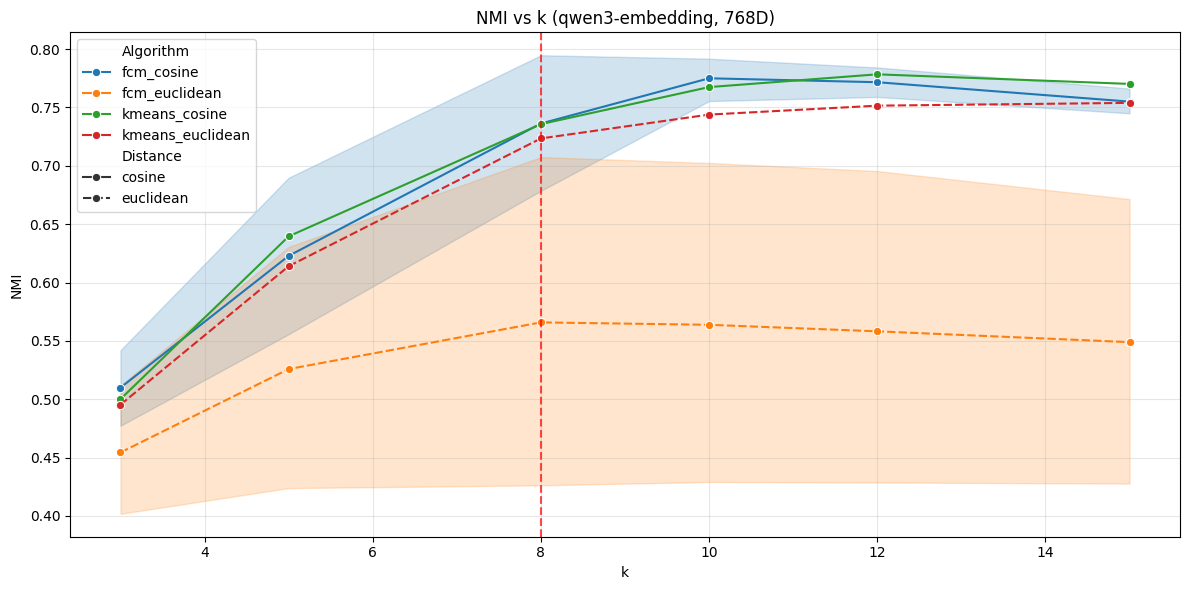

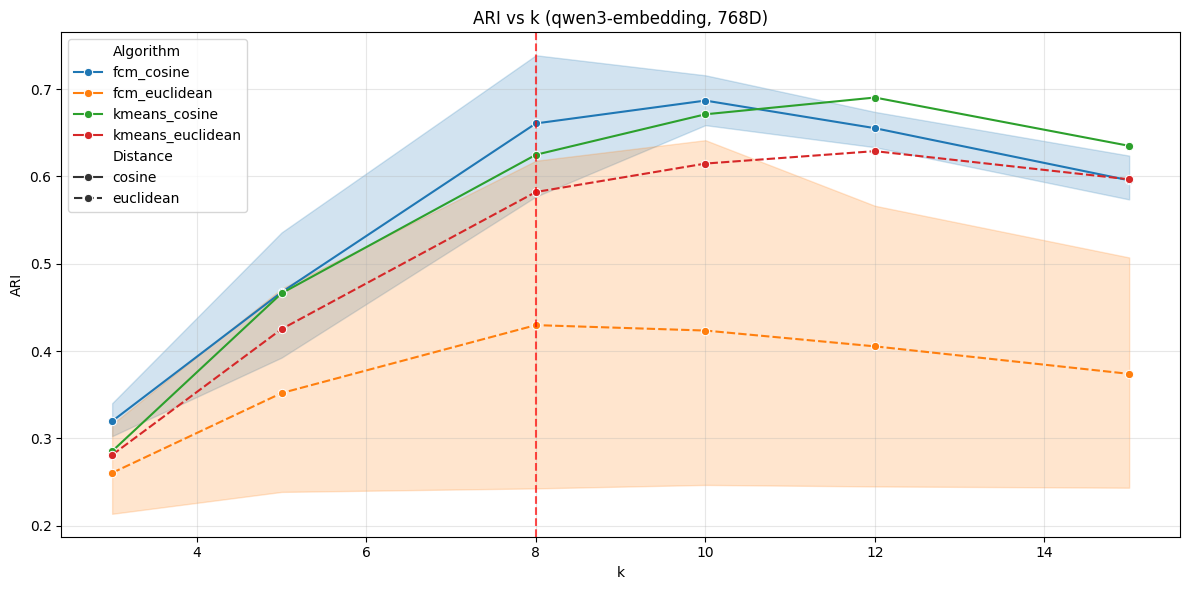

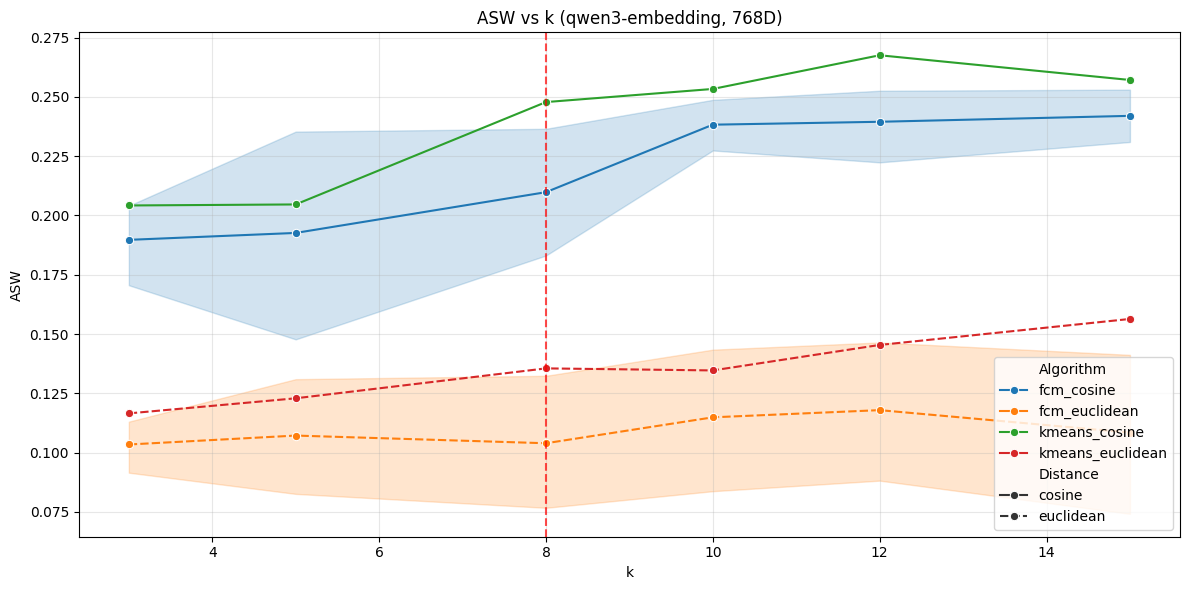

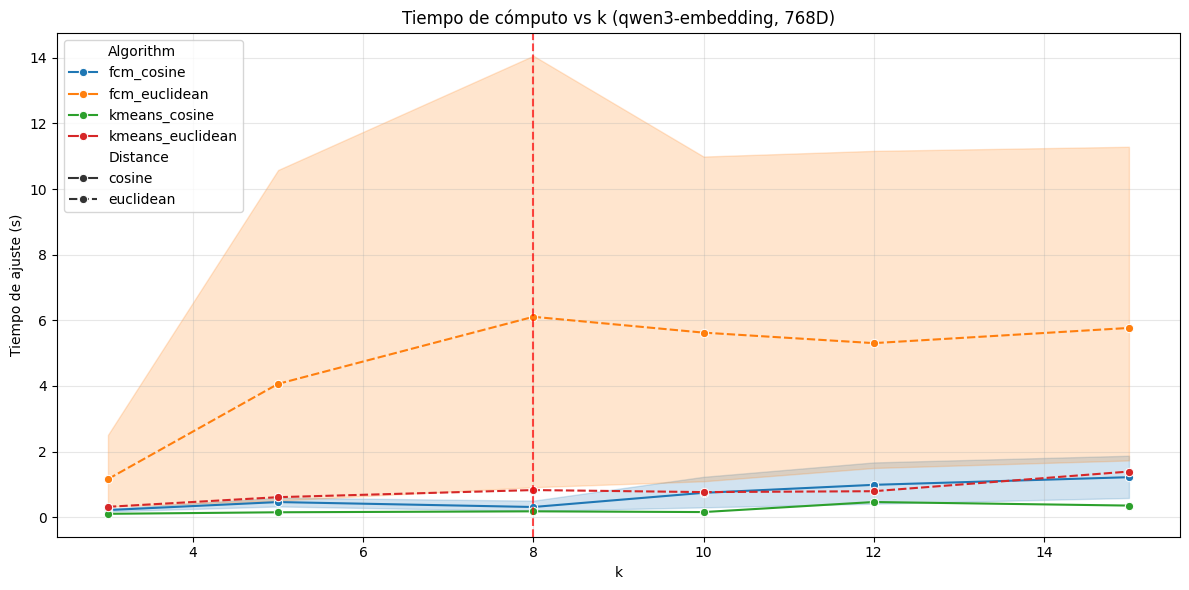

,Algorithm,Distance,k,m,FitTimeSec,NMI,ARI,ASW,CH,PC,PE,XB
13,fcm_cosine,cosine,8,1.20,0.209676,0.824026,0.788679,0.242404,101.534261,0.907168,0.189927,1.713445e+00
48,fcm_euclidean,euclidean,8,1.10,3.639429,0.817049,0.769592,0.153017,103.609080,0.907391,0.193171,1.467265e+00
14,fcm_cosine,cosine,8,1.40,0.198821,0.808586,0.763307,0.243210,102.188352,0.726444,0.615551,1.707418e+00
49,fcm_euclidean,euclidean,8,1.20,6.798791,0.805117,0.762226,0.152734,105.177668,0.699493,0.671694,2.003172e+00
12,fcm_cosine,cosine,8,1.10,0.149019,0.771633,0.684782,0.243433,100.760862,0.959838,0.072877,2.553388e+00
74,kmeans_cosine,cosine,8,NaN,0.178628,0.735716,0.624885,0.247807,94.522959,NaN,NaN,NaN
15,fcm_cosine,cosine,8,1.60,0.243505,0.731472,0.669506,0.203948,89.425082,0.397164,1.408294,1.607877e+07
80,kmeans_euclidean,euclidean,8,NaN,0.826876,0.723461,0.582218,0.135506,92.283780,NaN,NaN,NaN
16,fcm_cosine,cosine,8,1.80,0.280987,0.643438,0.535298,0.164936,80.801674,0.214114,1.853287,4.200162e+07
17,fcm_cosine,cosine,8,1.95,0.781706,0.638315,0.523003,0.160947,80.421712,0.189321,1.911217,2.915926e+07


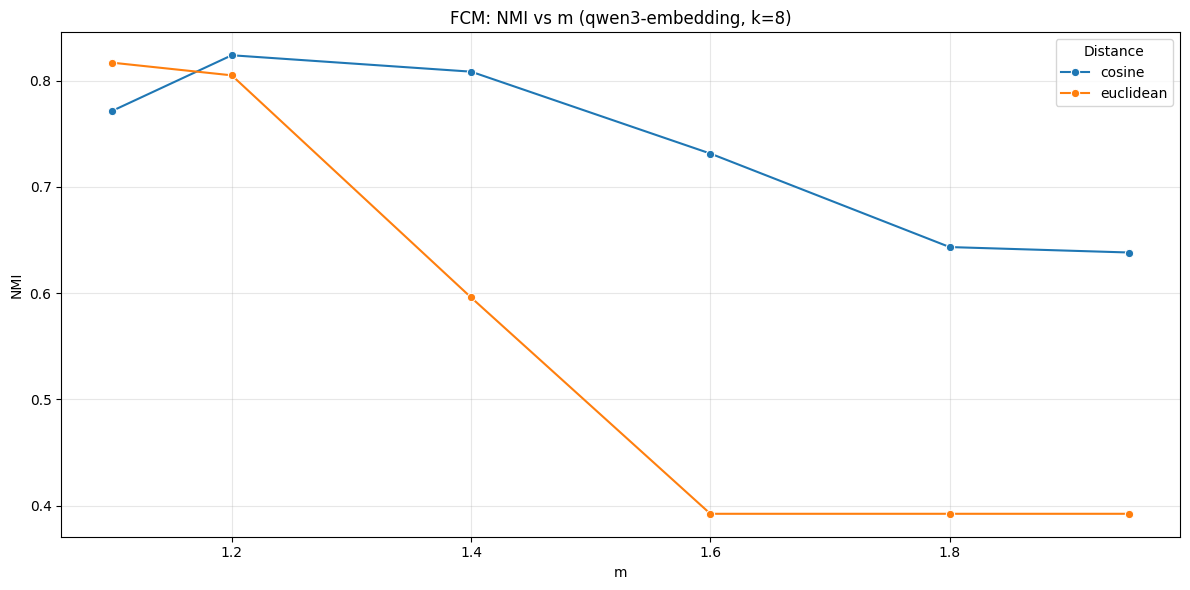

In [26]:
# Curvas NMI para todos los algoritmos en 768D
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_df, x="k", y="NMI", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("NMI vs k (qwen3-embedding, 768D)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nmi_vs_k_qwen3_768d.png", dpi=180, bbox_inches="tight")
plt.show()

# Curvas ARI para todos los algoritmos en 768D
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_df, x="k", y="ARI", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("ARI vs k (qwen3-embedding, 768D)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ari_vs_k_qwen3_768d.png", dpi=180, bbox_inches="tight")
plt.show()

# Curvas ASW para todos los algoritmos en 768D
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_df, x="k", y="ASW", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("ASW vs k (qwen3-embedding, 768D)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "asw_vs_k_qwen3_768d.png", dpi=180, bbox_inches="tight")
plt.show()

# Curvas de tiempo de cómputo para todos los algoritmos en 768D
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_df, x="k", y="FitTimeSec", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("Tiempo de cómputo vs k (qwen3-embedding, 768D)")
ax.set_ylabel("Tiempo de ajuste (s)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "time_vs_k_qwen3_768d.png", dpi=180, bbox_inches="tight")
plt.show()

comparison_k8 = summary_df[summary_df["k"] == 8].sort_values(["NMI", "ARI"], ascending=False)
display(
    comparison_k8[
        ["Algorithm", "Distance", "k", "m", "FitTimeSec", "NMI", "ARI", "ASW", "CH", "PC", "PE", "XB"]
    ].head(20)
)

# Efecto de m en FCM (NMI), fijando k=8
fcm_k8 = summary_df[(summary_df["Algorithm"].str.contains("fcm")) & (summary_df["k"] == 8)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=fcm_k8, x="m", y="NMI", hue="Distance", marker="o", ax=ax)
ax.set_title("FCM: NMI vs m (qwen3-embedding, k=8)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fcm_nmi_vs_m_k8_qwen3_768d.png", dpi=180, bbox_inches="tight")
plt.show()

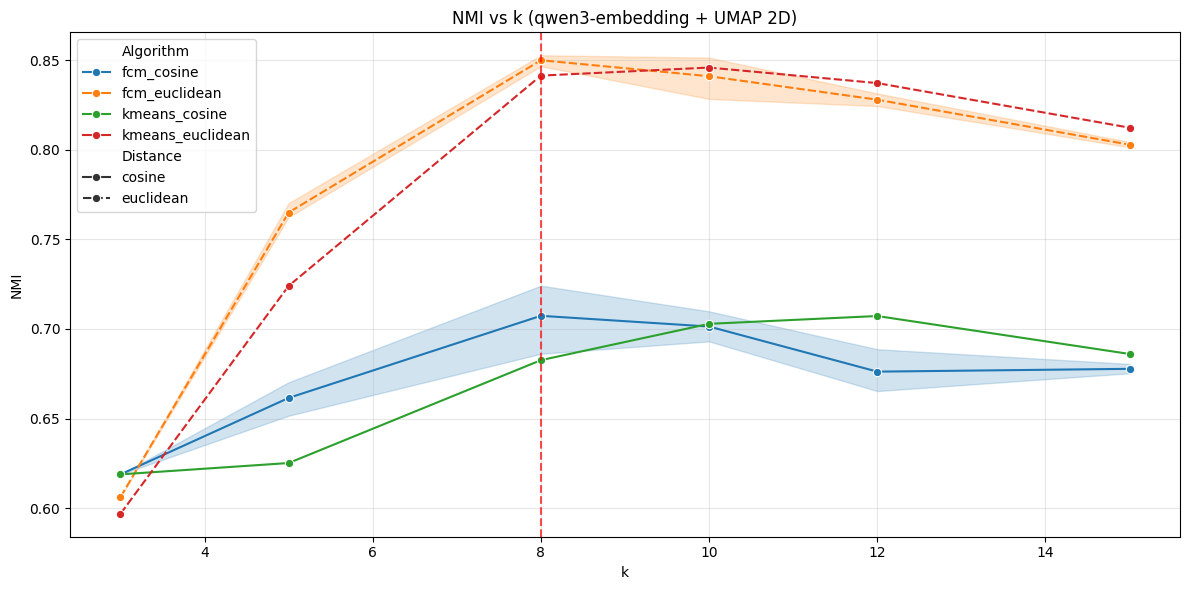

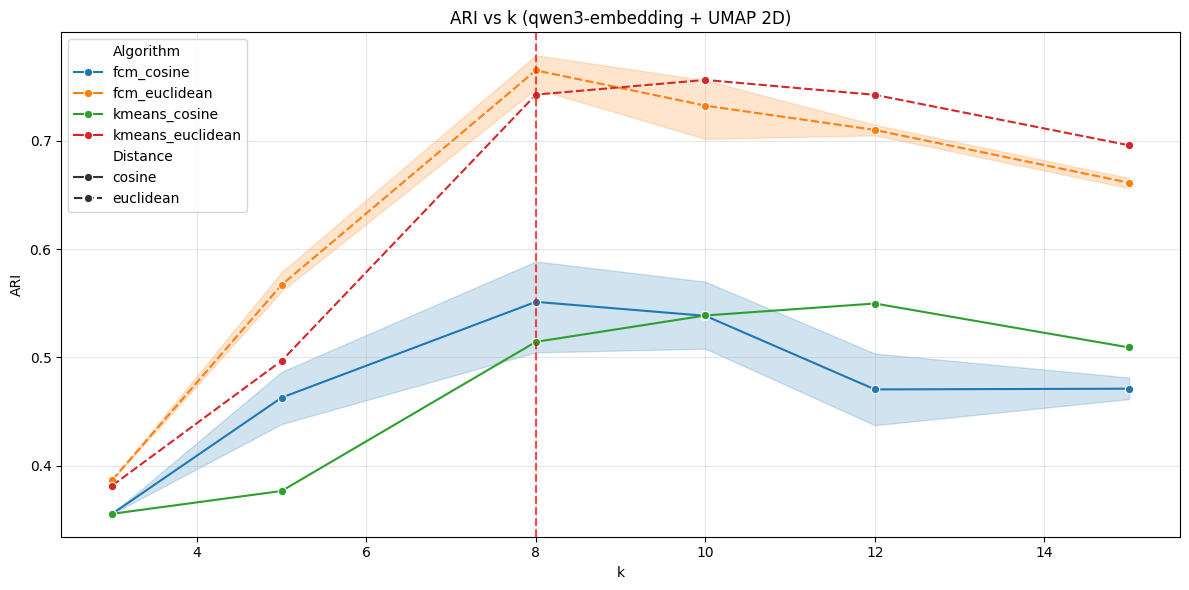

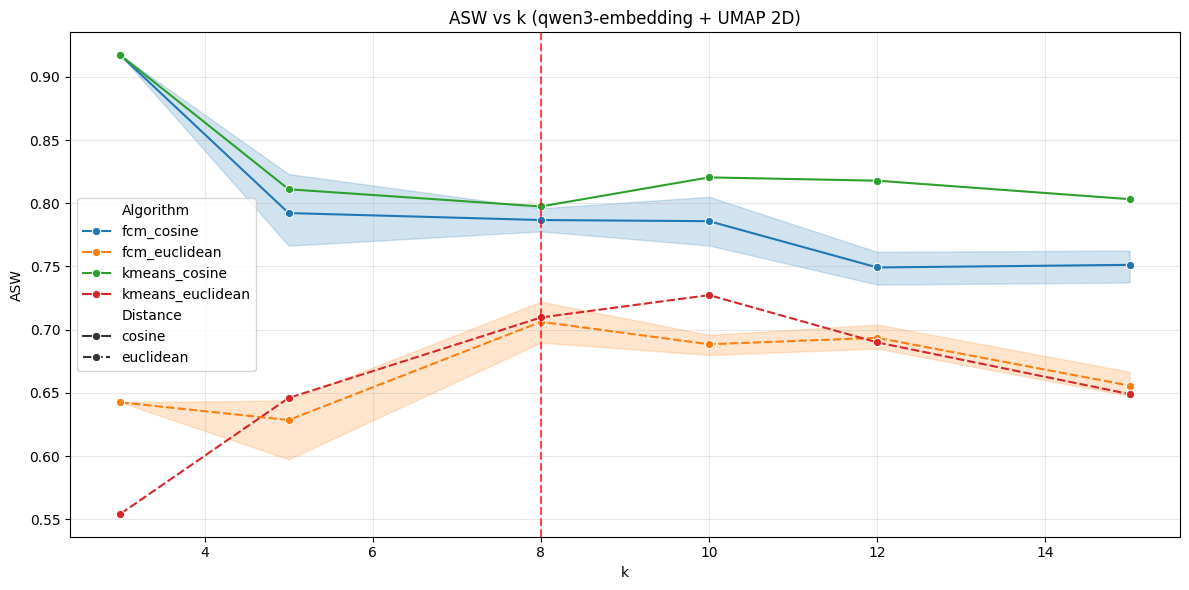

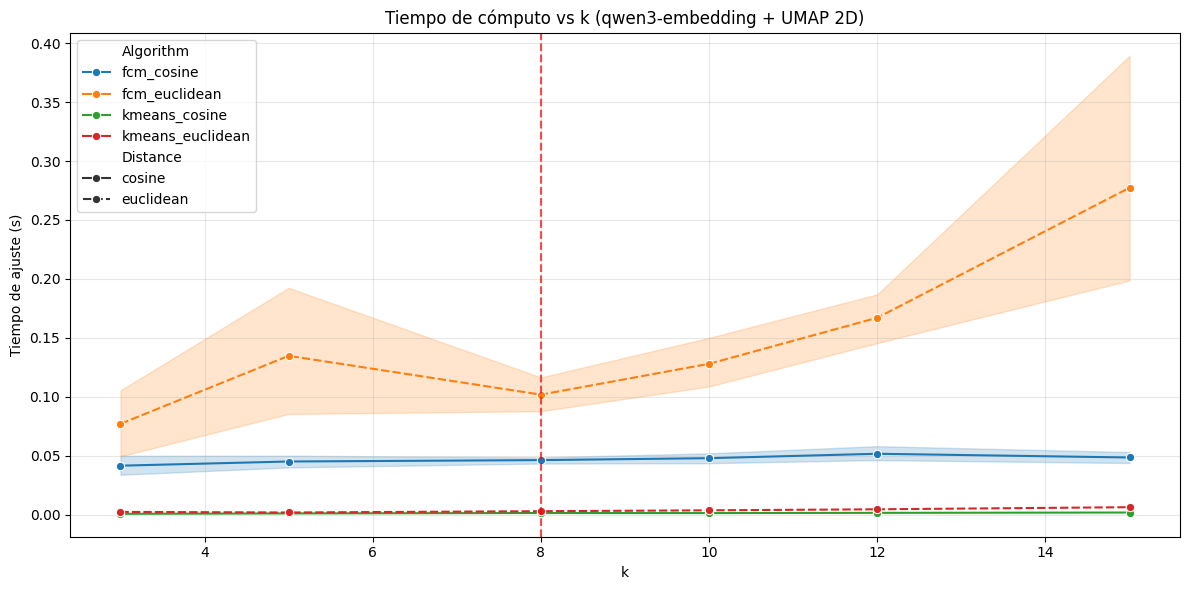

,Algorithm,Distance,k,m,FitTimeSec,NMI,ARI,ASW,CH,PC,PE,XB
50,fcm_euclidean,euclidean,8,1.40,0.101165,0.854355,0.754355,0.691482,4543.705973,0.978162,0.051773,0.507312
48,fcm_euclidean,euclidean,8,1.10,0.073616,0.853880,0.789070,0.698922,4953.628418,0.999404,0.001331,0.734204
53,fcm_euclidean,euclidean,8,1.95,0.130926,0.849900,0.774024,0.726653,6790.441895,0.834811,0.403442,0.079821
51,fcm_euclidean,euclidean,8,1.60,0.099829,0.849534,0.773408,0.726829,6791.870443,0.956776,0.108834,0.095164
52,fcm_euclidean,euclidean,8,1.80,0.113013,0.849534,0.773408,0.726829,6791.870768,0.895146,0.260566,0.087783
49,fcm_euclidean,euclidean,8,1.20,0.092087,0.842094,0.724754,0.666639,4100.344076,0.996744,0.007397,1.440532
80,kmeans_euclidean,euclidean,8,NaN,0.002874,0.841301,0.742432,0.709664,4639.087321,NaN,NaN,NaN
17,fcm_cosine,cosine,8,1.95,0.043757,0.735563,0.620043,0.788356,640.228027,0.933908,0.125669,17.753484
16,fcm_cosine,cosine,8,1.80,0.040483,0.719189,0.574683,0.774165,638.208537,0.947588,0.097287,30.585135
12,fcm_cosine,cosine,8,1.10,0.047619,0.717952,0.573081,0.783253,651.616292,0.995726,0.007373,27.809468


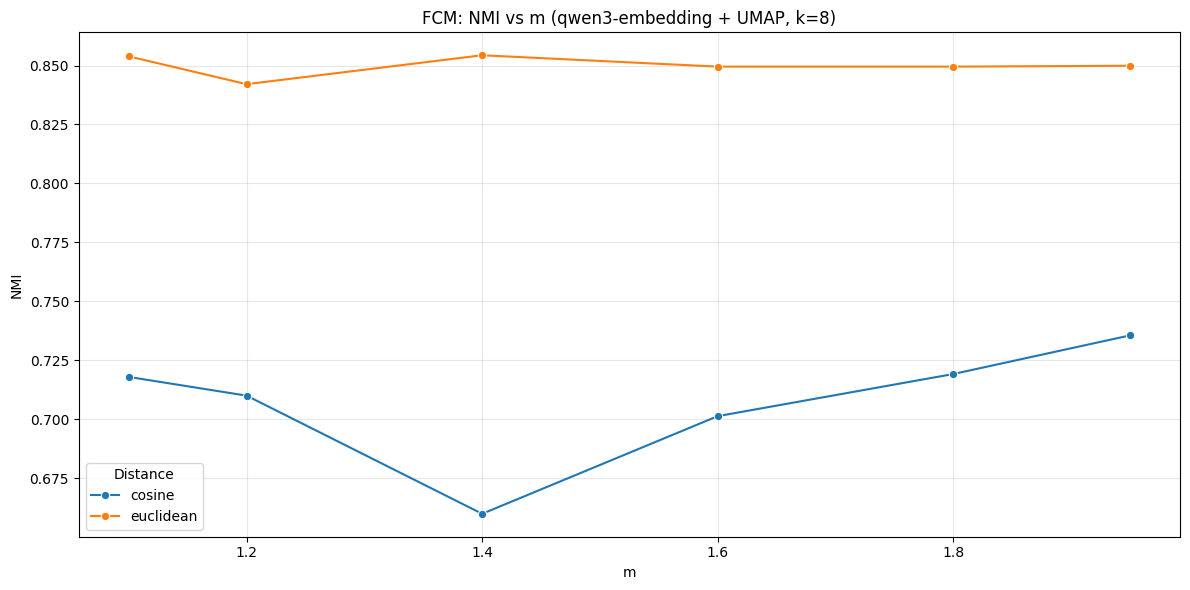

In [25]:
# Comparativa NMI en UMAP
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_umap_df, x="k", y="NMI", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("NMI vs k (qwen3-embedding + UMAP 2D)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nmi_vs_k_qwen3_umap.png", dpi=180, bbox_inches="tight")
plt.show()

# Comparativa ARI en UMAP
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_umap_df, x="k", y="ARI", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("ARI vs k (qwen3-embedding + UMAP 2D)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ari_vs_k_qwen3_umap.png", dpi=180, bbox_inches="tight")
plt.show()

# Comparativa ASW en UMAP
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_umap_df, x="k", y="ASW", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("ASW vs k (qwen3-embedding + UMAP 2D)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "asw_vs_k_qwen3_umap.png", dpi=180, bbox_inches="tight")
plt.show()

# Comparativa de tiempo de cómputo en UMAP
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=summary_umap_df, x="k", y="FitTimeSec", hue="Algorithm", style="Distance", marker="o", ax=ax)
ax.set_title("Tiempo de cómputo vs k (qwen3-embedding + UMAP 2D)")
ax.set_ylabel("Tiempo de ajuste (s)")
ax.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="True k=8")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "time_vs_k_qwen3_umap.png", dpi=180, bbox_inches="tight")
plt.show()

comparison_k8_umap = summary_umap_df[summary_umap_df["k"] == 8].sort_values(["NMI", "ARI"], ascending=False)
display(
    comparison_k8_umap[
        ["Algorithm", "Distance", "k", "m", "FitTimeSec", "NMI", "ARI", "ASW", "CH", "PC", "PE", "XB"]
    ].head(20)
)

fcm_k8_umap = summary_umap_df[(summary_umap_df["Algorithm"].str.contains("fcm")) & (summary_umap_df["k"] == 8)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=fcm_k8_umap, x="m", y="NMI", hue="Distance", marker="o", ax=ax)
ax.set_title("FCM: NMI vs m (qwen3-embedding + UMAP, k=8)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fcm_nmi_vs_m_k8_qwen3_umap.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Mejor configuración y validación cualitativa (escenario original)

In [13]:
best_row = summary_df.sort_values(by=["NMI", "ARI"], ascending=False).iloc[0]
best_algorithm = best_row["Algorithm"]
best_distance = best_row["Distance"]
best_k = int(best_row["k"])
best_m = best_row["m"]

explore_seed = 42
if pd.isna(best_m):
    best_key = f"{best_algorithm}_k{best_k}_s{explore_seed}"
else:
    best_key = f"{best_algorithm}_m{best_m}_k{best_k}_s{explore_seed}"

cached = models_cache[best_key]
model = cached["model"]
pred_labels = cached["labels"]

print("Mejor configuración (original 768D):")
print(best_row[["Algorithm", "Distance", "k", "m", "NMI", "ARI"]])

representatives_idx = get_closest_to_centroid(
    embeddings,
    pred_labels,
    model.centroids_,
    distance=best_distance,
)

for cluster_id, rep_idx in enumerate(representatives_idx):
    rep_text = df.iloc[rep_idx]["text"]
    rep_true = df.iloc[rep_idx]["label"]
    print(f"\n--- Cluster {cluster_id} ---")
    print(f"Centroide representativo: '{rep_text}' (real: {rep_true})")

Mejor configuración (original 768D):
Algorithm    fcm_cosine
Distance         cosine
k                     8
m                   1.2
NMI            0.824026
ARI            0.788679
Name: 13, dtype: object

--- Cluster 0 ---
Centroide representativo: 'Can you tell me when my card will arrive?' (real: card_delivery_estimate)

--- Cluster 1 ---
Centroide representativo: 'Why have I been charged a fee for cash withdrawal?' (real: cash_withdrawal_charge)

--- Cluster 2 ---
Centroide representativo: 'There's a payment that isn't mine on my app' (real: card_payment_not_recognised)

--- Cluster 3 ---
Centroide representativo: 'I see a cash withdrawal in the app that I did not do.' (real: cash_withdrawal_not_recognised)

--- Cluster 4 ---
Centroide representativo: 'For some reason I am unable to preform a transfer to a beneficiary.' (real: beneficiary_not_allowed)

--- Cluster 5 ---
Centroide representativo: 'My card doesn't seem to work.' (real: card_not_working)

--- Cluster 6 ---
Centroide r

## 8. Carga rápida de resultados guardados

In [14]:
results_raw = pd.read_csv(TABLES_DIR / "results_raw_qwen3.csv")
results_summary = pd.read_csv(TABLES_DIR / "results_summary_qwen3.csv")
results_umap_raw = pd.read_csv(TABLES_DIR / "results_umap_raw_qwen3.csv")
results_umap_summary = pd.read_csv(TABLES_DIR / "results_umap_summary_qwen3.csv")

print("Resultados cargados correctamente:")
print(f"- Original raw: {results_raw.shape}")
print(f"- Original summary: {results_summary.shape}")
print(f"- UMAP raw: {results_umap_raw.shape}")
print(f"- UMAP summary: {results_umap_summary.shape}")

Resultados cargados correctamente:
- Original raw: (252, 12)
- Original summary: (84, 12)
- UMAP raw: (252, 12)
- UMAP summary: (84, 12)
